# 11 · Detecting pop-ins (refreshed classic)

*Find sudden displacement bursts in indentation curves — and prove the detector works first.*

> ⏱ **Runtime:** ~5 s on a laptop CPU (no GPU) · 🎓 **Level:** beginner · 📊 **Data:** raw load–depth curves

### 🎯 What you'll learn
1. what a **pop-in** is and why it matters mechanically,
2. a **transparent** detector (no training, no black box): a spike in **dh/dP**,
3. how a **robust (MAD) threshold** finds spikes without being fooled by noise,
4. why you should **validate a detector on a known signal** before trusting it.

### 🧭 What you need to know first
- The idea of a load–depth curve (notebook 00).
- No machine learning needed — this is signal processing you can fully explain.

> 🧠 **What is a pop-in?** During loading, the tip usually sinks smoothly as force rises. A
> **pop-in** is a sudden jump in depth at almost constant load — a little horizontal step in the
> curve. Physically it signals **dislocation nucleation** or a tiny fracture event. Because depth
> jumps while load barely moves, the ratio **dh/dP** (change in depth per change in load) spikes
> right there. That spike is what we detect.

### Step 0: set-up

Start by running the setup cell. Click it and hit **Shift + Enter**.

> 🟢 **On Colab** it clones the repo and installs the few packages Colab lacks, so give it about a minute. After a local `pip install -r requirements.txt` there is nothing to wait for.

> ✅ **You should see:** a line like `helpers loaded from: .../mecanano_ml/__init__.py`. That confirms the helper package loaded correctly.

In [1]:
# --- Setup cell — run me first! ---------------------------------------------
# It makes the helper package `mecanano_ml` importable and sets a clean plot
# style. You do not need to understand every line here; just run it.
# On Google Colab it also clones the repo and installs the few extra packages
# Colab doesn't ship (takes ~1 min, once per session).
import os, sys, subprocess

def _find_src():
    # Look for the repo's src/ folder in the usual places (local clone / Colab).
    for p in ("../src", "src", "mecanano-ml-nanomechanics/src"):
        if os.path.isdir(p):
            return p
    return None

if "google.colab" in sys.modules:             # running on Colab -> set everything up
    # packages Colab does not preinstall (torch/sklearn/etc. are already there):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "hdbscan", "umap-learn", "pyts", "shap", "imbalanced-learn"],
                   check=False)

if _find_src() is None:                       # bare session (e.g. Colab): fetch the repo
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/edrossi93/mecanano-ml-nanomechanics.git"],
                   check=False)

sys.path.insert(0, os.path.abspath(_find_src() or "mecanano-ml-nanomechanics/src"))

import numpy as np                 # arrays and maths
import pandas as pd                # tables (each row = one indent)
import matplotlib.pyplot as plt    # plotting
import mecanano_ml as mm           # our tiny helper package: loaders + plotting
mm.set_style()                     # consistent, publication-like figures
# Confirm the helpers loaded (just the tail of the path, not your machine's folders).
_pkg = os.path.basename(os.path.dirname(mm.__file__))
print("helpers loaded from: .../" + _pkg + "/" + os.path.basename(mm.__file__))

helpers loaded from: .../mecanano_ml/__init__.py


> 🧠 **dh/dP** — how much the depth changes for a small change in load. Smooth loading = small, steady dh/dP; a pop-in = a sharp spike.

> 🧠 **MAD (median absolute deviation)** — a robust measure of spread: the median distance of points from their median. Unlike the standard deviation, a few wild values barely move it — perfect for spotting rare spikes.

> 🧠 **robust z-score** — how many MADs a point sits above the typical value. We flag a pop-in when this score exceeds a threshold (here 6).

In [2]:
from scipy.ndimage import uniform_filter1d

def loading_segment(depth, load):
    k = int(np.argmax(load))                      # everything up to maximum load = the loading branch
    return depth[:k + 1], load[:k + 1]

def find_popins(depth, load, k_mad=6, min_load=0.2):
    """Flag indices where dh/dP is anomalously large (a displacement burst)."""
    h = uniform_filter1d(depth.astype(float), 3)  # light smoothing to tame pixel noise
    P = uniform_filter1d(load.astype(float), 3)
    dP = np.gradient(P); dh = np.gradient(h)       # local changes along the curve
    ratio = dh / np.where(np.abs(dP) < 1e-6, np.nan, dP)   # dh/dP, guarding divide-by-zero
    ratio[P < min_load] = np.nan                   # ignore the noisy surface-approach region
    med = np.nanmedian(ratio)                      # typical dh/dP
    mad = np.nanmedian(np.abs(ratio - med)) + 1e-9  # robust spread
    score = (ratio - med) / (1.4826 * mad)         # robust z-score (1.4826 makes MAD ~ std for normal data)
    return np.where(score > k_mad)[0], score       # indices above threshold, and the full score

## 1 · Validate on a synthetic curve

**Trust, but verify.** Before running the detector on real data, we build a clean elastic–plastic
curve and inject a 12 nm burst at a **known** load. A good detector must flag the pop-in *exactly there*.

> ✅ **You should see:** left: the synthetic curve with the detected pop-in marked in red, right on the injected step; right: the dh/dP score with one clear spike above the threshold line.

detected near injected index: [ 11  12  13  14  15  16 178 179 180 181]  (true = 180 )


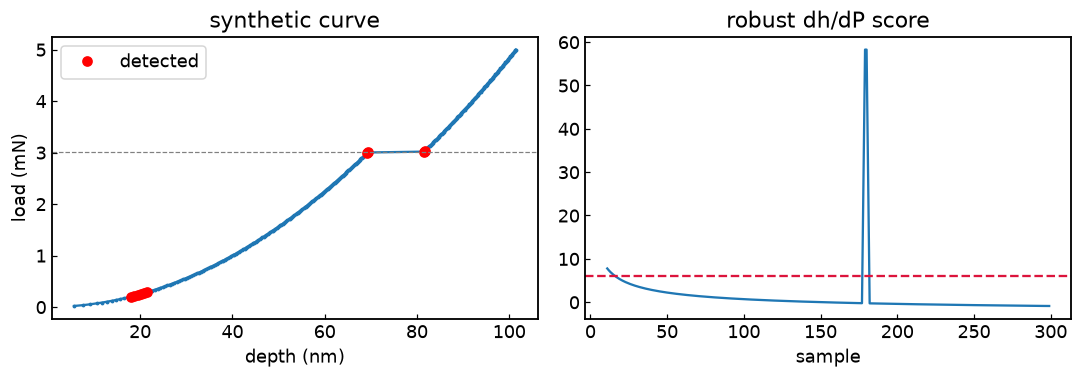

In [3]:
P = np.linspace(0.02, 5, 300)
h = 40 * np.sqrt(P)                                # smooth elastic–plastic baseline
k_true = 180; h[k_true:] += 12.0                   # <-- inject a 12 nm pop-in at a KNOWN index
idx, score = find_popins(h, P)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].plot(h, P, ".-", ms=3); ax[0].plot(h[idx], P[idx], "ro", label="detected")
ax[0].axhline(P[k_true], color="grey", ls="--", lw=.8); ax[0].set_xlabel("depth (nm)")
ax[0].set_ylabel("load (mN)"); ax[0].legend(); ax[0].set_title("synthetic curve")
ax[1].plot(score); ax[1].axhline(6, color="crimson", ls="--"); ax[1].set_title("robust dh/dP score")
ax[1].set_xlabel("sample"); fig.tight_layout()
print("detected near injected index:", idx, " (true =", k_true, ")")

*🖼 **Figure.** This is our 'labelled' pop-in: we know it sits at the grey dashed load. The detector's red marker lands on it and the score (right) spikes above the threshold exactly once — the method works.*

### ✅ Self-check
Sanity-check the output above. Should a future edit break a result, the assert below trips with an `AssertionError` and flags it right away.

In [4]:
# Each line fails loudly if a key result drifts out of a sensible range.
# (These also run in CI, so a broken result fails the build.)
assert np.min(np.abs(idx - k_true)) <= 3, "the detector should flag the injected pop-in"
print("self-check passed ✓ — the injected pop-in was found")

self-check passed ✓ — the injected pop-in was found


## 2 · Apply to real load–depth curves

Now run the *same* detector over real indents and mark any bursts on the loading branch.

> ✅ **You should see:** a 3×4 grid of real loading curves with any detected pop-ins marked as red dots, and a total count in the title.

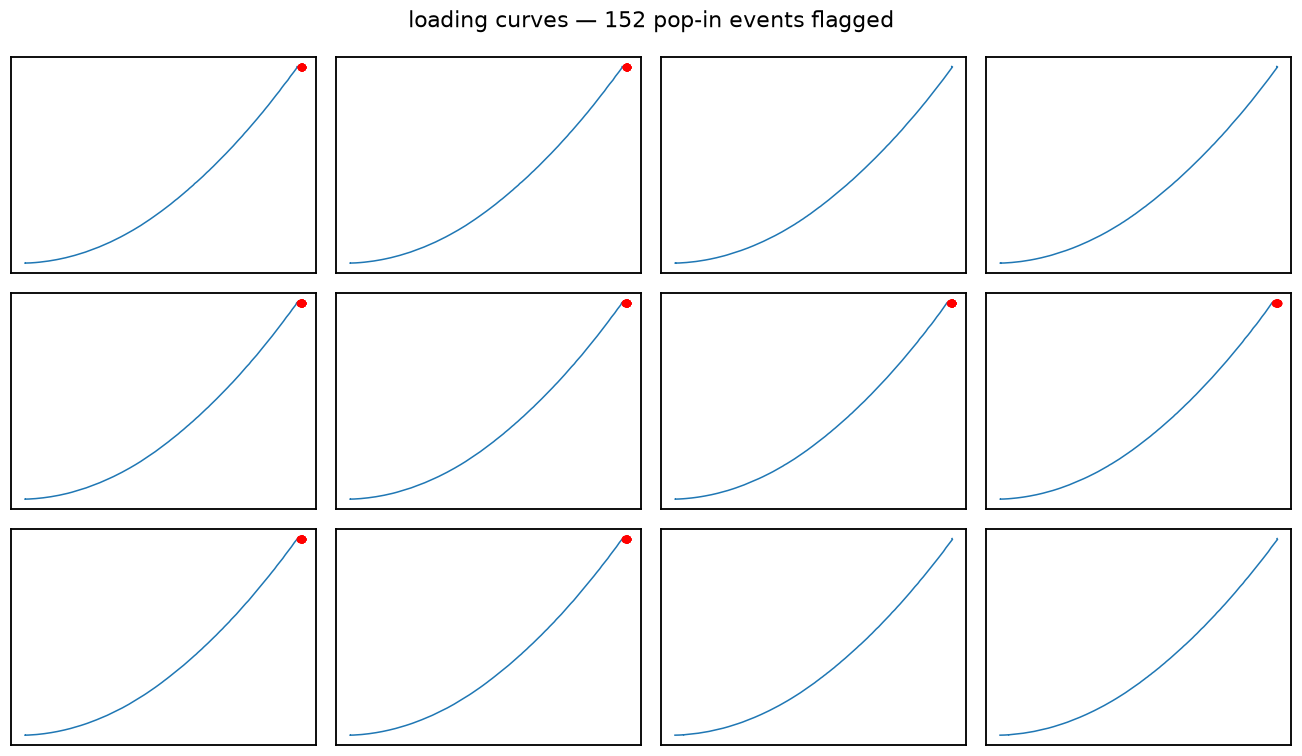

In [5]:
curves = mm.load_curves(12)
fig, ax = plt.subplots(3, 4, figsize=(12, 7))
n_found = 0
for a, (d, l) in zip(ax.ravel(), curves):
    h, P = loading_segment(d, l)                   # analyse only the loading branch
    idx, _ = find_popins(h, P)
    n_found += len(idx)
    a.plot(h, P, lw=1); a.plot(h[idx], P[idx], "ro", ms=4)
    a.set_xticks([]); a.set_yticks([])
fig.suptitle(f"loading curves — {n_found} pop-in events flagged"); fig.tight_layout()

*🖼 **Figure.** Red dots mark flagged bursts on real curves. Not every curve has a pop-in; that's expected. Because we validated first, we can trust these flags.*

## ✅ Recap
- A pop-in is a **dh/dP anomaly**; a **robust (MAD) threshold** finds it with no training and no black box.
- **Validate a detector on a known signal** (here a synthetic pop-in) before trusting it on real curves.
- These flags feed naturally into the autoencoder anomaly score (notebook 05) and curve classification (notebook 04).

## 🔧 Try it yourself
A few small experiments (re-run the cell after each):
1. Lower the sensitivity threshold `k_mad` from 6 to 4 in `find_popins`. Do you catch more real pop-ins, or more false alarms?
2. Shrink the injected burst in Section 1 from 12 nm to 3 nm. Is it still detected?
3. Load more real curves — `mm.load_curves(24)` — and count how many show a pop-in.

## 🩹 Common errors & fixes
- **No pop-ins detected anywhere** → your threshold may be too high, or `min_load` is cutting off the region; lower `k_mad` or `min_load`.
- **Everything is flagged** → threshold too low; raise `k_mad`. Real detectors need tuning on a few known curves.
- **`RuntimeWarning: invalid value`** → harmless; it comes from the guarded divide-by-zero in dh/dP.

---
**Next:** **`12_regression_curvefitting.ipynb`** — fit physics to a curve, then predict hardness with regression.